In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [7]:
df = pd.read_csv(r'D:\pro\mlpro\notebook\data\stud.csv')

In [8]:

X = df.drop(columns=['math_score'],axis=1)

In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:

print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [11]:

y = df['math_score']

In [12]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [13]:

# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [15]:
X = preprocessor.fit_transform(X)

In [16]:
X.shape

(1000, 19)

In [17]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [18]:

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    # Comment out CatBoost if not installed
    # "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}


In [23]:
model_list = []
r2_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    print(name)
    print("Training set:")
    print(f"- RMSE: {train_rmse:.4f}")
    print(f"- MAE: {train_mae:.4f}")
    print(f"- R²: {train_r2:.4f}")
    print("Test set:")
    print(f"- RMSE: {test_rmse:.4f}")
    print(f"- MAE: {test_mae:.4f}")
    print(f"- R²: {test_r2:.4f}")
    print("="*35)

    # Append results
    model_list.append(name)
    r2_list.append(test_r2)


Linear Regression
Training set:
- RMSE: 5.3231
- MAE: 4.2667
- R²: 0.8743
Test set:
- RMSE: 5.3940
- MAE: 4.2148
- R²: 0.8804
Lasso
Training set:
- RMSE: 6.5938
- MAE: 5.2063
- R²: 0.8071
Test set:
- RMSE: 6.5197
- MAE: 5.1579
- R²: 0.8253
Ridge
Training set:
- RMSE: 5.3233
- MAE: 4.2650
- R²: 0.8743
Test set:
- RMSE: 5.3904
- MAE: 4.2111
- R²: 0.8806
K-Neighbors Regressor
Training set:
- RMSE: 5.7133
- MAE: 4.5217
- R²: 0.8552
Test set:
- RMSE: 7.2412
- MAE: 5.6110
- R²: 0.7845
Decision Tree
Training set:
- RMSE: 0.2795
- MAE: 0.0187
- R²: 0.9997
Test set:
- RMSE: 7.4713
- MAE: 5.8300
- R²: 0.7706
Random Forest Regressor
Training set:
- RMSE: 2.2855
- MAE: 1.8282
- R²: 0.9768
Test set:
- RMSE: 6.0966
- MAE: 4.6876
- R²: 0.8473
XGBRegressor
Training set:
- RMSE: 1.0073
- MAE: 0.6875
- R²: 0.9955
Test set:
- RMSE: 6.4733
- MAE: 5.0577
- R²: 0.8278
AdaBoost Regressor
Training set:
- RMSE: 5.8407
- MAE: 4.7723
- R²: 0.8487
Test set:
- RMSE: 6.1223
- MAE: 4.7656
- R²: 0.8460


In [24]:
results = pd.DataFrame({
    "Model": model_list,
    "Test R²": r2_list
}).sort_values(by="Test R²", ascending=False)

print(results)


                     Model   Test R²
2                    Ridge  0.880593
0        Linear Regression  0.880433
5  Random Forest Regressor  0.847254
7       AdaBoost Regressor  0.845966
6             XGBRegressor  0.827797
1                    Lasso  0.825320
3    K-Neighbors Regressor  0.784518
4            Decision Tree  0.770608


C:\Users\dhuma\AppData\Local\Temp\ipykernel_30944\1769318704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test R²", data=results, palette="viridis")


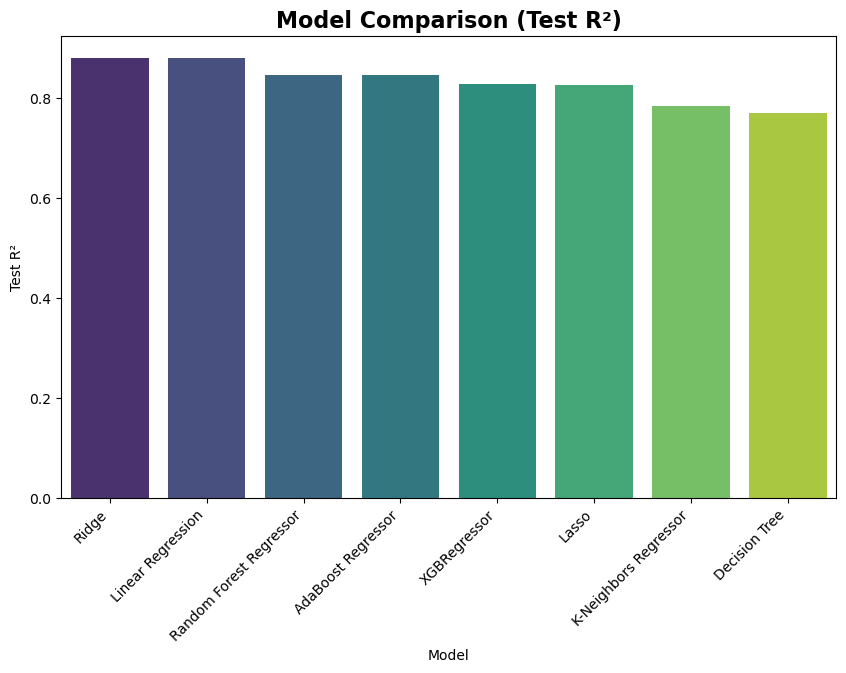

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Test R²", data=results, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison (Test R²)", fontsize=16, fontweight="bold")
plt.show()


In [26]:

lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


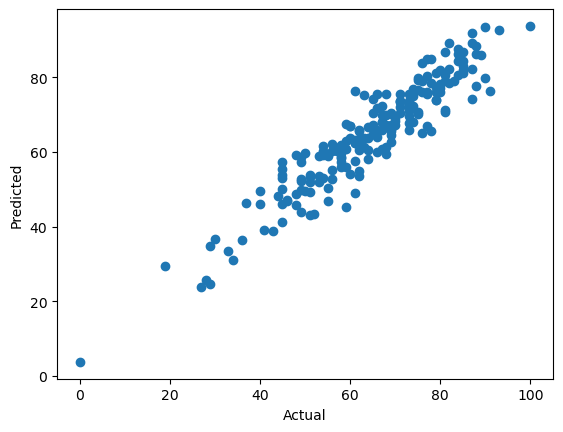

In [27]:

plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

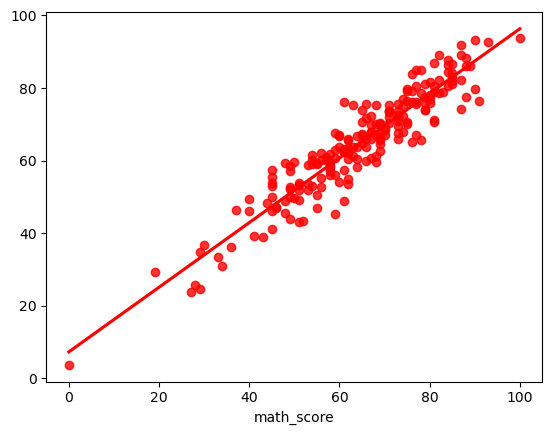

In [28]:

sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [29]:

pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
